In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['price'] = data.target
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [4]:
df.shape

(20640, 9)

In [5]:
# data is too big so we will take only 20% for our implementation
df = df.sample(frac=0.2)
df.shape

(4128, 9)

In [6]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [7]:
y

224      1.871
1859     1.224
782      1.630
3044     0.611
7002     1.582
         ...  
1171     0.576
5779     2.523
10441    2.521
6948     1.639
17249    3.625
Name: price, Length: 4128, dtype: float64

In [8]:
# train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [9]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape


((3302, 8), (826, 8), (3302,), (826,))

In [10]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [11]:
y_pred = dt.predict(x_test)
y_pred

array([2.391  , 0.875  , 2.257  , 5.00001, 2.481  , 1.461  , 1.486  ,
       1.099  , 2.385  , 4.167  , 2.455  , 1.941  , 1.817  , 1.405  ,
       1.91   , 2.15   , 2.554  , 0.388  , 1.826  , 0.8    , 5.00001,
       2.098  , 0.979  , 0.633  , 1.963  , 1.75   , 2.972  , 1.533  ,
       1.91   , 0.664  , 1.578  , 0.9    , 1.449  , 1.018  , 1.3    ,
       5.00001, 3.088  , 1.955  , 0.855  , 1.138  , 1.494  , 1.485  ,
       3.093  , 1.704  , 1.459  , 3.205  , 1.322  , 1.5    , 2.467  ,
       0.433  , 2.161  , 0.876  , 1.353  , 4.5    , 1.686  , 0.742  ,
       1.     , 2.623  , 2.391  , 0.886  , 3.964  , 1.734  , 1.5    ,
       2.386  , 2.663  , 2.321  , 0.67   , 4.329  , 2.433  , 1.158  ,
       2.18   , 0.603  , 2.171  , 1.65   , 2.824  , 2.375  , 1.185  ,
       2.42   , 0.631  , 3.964  , 1.137  , 1.211  , 5.00001, 1.331  ,
       2.84   , 0.63   , 0.944  , 2.707  , 2.875  , 0.75   , 0.933  ,
       4.276  , 1.437  , 1.9    , 1.33   , 1.259  , 3.496  , 3.452  ,
       2.188  , 3.45

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
r2_score(y_test, y_pred)

0.5134303175717958

In [13]:
# hyperparameter tuning
params ={
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse', 'poisson'],
    'splitter' : ['best', 'random'],
    'max_depth': [1, 2, 3, 4,10],
    'max_features':['sqrt', 'log2', 'auto']
}


In [14]:
dt = DecisionTreeRegressor()

In [15]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(dt, param_grid = params, cv=5,scoring = "neg_mean_squared_error", verbose = 3)

grid.fit(x_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV 1/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-1.308 total time=   0.0s
[CV 2/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-0.971 total time=   0.0s
[CV 3/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-1.323 total time=   0.0s
[CV 4/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-0.913 total time=   0.0s
[CV 5/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-0.901 total time=   0.0s
[CV 1/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=random;, score=-1.296 total time=   0.0s
[CV 2/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=random;, score=-1.145 total time=   0.0s
[CV 3/5] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=random;, score=-1.357 total 

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'absolute_error', ...], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [16]:
grid.best_params_

{'criterion': 'squared_error',
 'max_depth': 10,
 'max_features': 'log2',
 'splitter': 'best'}

In [17]:
final_model = DecisionTreeRegressor(criterion='poisson', max_depth=10, max_features='log2', splitter='best')
final_model.fit(x_train, y_train)

,criterion,'poisson'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [18]:
final_model.predict(x_test)

array([1.42041667, 0.87666071, 3.10903138, 4.22660467, 2.13014706,
       1.73132432, 1.36592308, 1.1286    , 1.86613514, 1.531     ,
       1.052     , 3.58625   , 3.5945    , 1.86613514, 2.60456146,
       2.38120513, 1.239     , 1.39797917, 1.63      , 0.74666667,
       4.99942625, 1.71630159, 1.73132432, 0.7695    , 3.5       ,
       1.104     , 3.5285    , 1.71630159, 1.73132432, 1.11111111,
       1.44988889, 0.68133333, 1.56735294, 1.19954545, 1.196     ,
       1.349     , 1.94033333, 1.719     , 1.12491667, 1.0316129 ,
       1.39797917, 1.084     , 3.10903138, 1.56985714, 1.65463889,
       2.9275    , 1.281875  , 1.62495652, 1.86613514, 3.1       ,
       1.531     , 1.65463889, 1.18466667, 1.528     , 1.87505714,
       0.74666667, 0.84511111, 2.5755    , 2.41015385, 0.74666667,
       2.665     , 1.734     , 1.49444444, 2.41015385, 3.15789321,
       3.28916667, 0.87666071, 3.38892462, 2.60456146, 1.8495625 ,
       1.71630159, 0.6335    , 1.62495652, 0.87666071, 3.28916

[Text(0.5974298981640849, 0.9545454545454546, 'x[5] <= 2.971\npoisson = 0.298\nsamples = 3302\nvalue = 2.066'),
 Text(0.3479005306942054, 0.8636363636363636, 'x[6] <= 37.975\npoisson = 0.321\nsamples = 1946\nvalue = 2.303'),
 Text(0.4726652144291451, 0.9090909090909092, 'True  '),
 Text(0.21589931153184166, 0.7727272727272727, 'x[2] <= 6.414\npoisson = 0.299\nsamples = 1541\nvalue = 2.547'),
 Text(0.131131669535284, 0.6818181818181818, 'x[7] <= -117.765\npoisson = 0.269\nsamples = 1289\nvalue = 2.361'),
 Text(0.06848823866896156, 0.5909090909090909, 'x[0] <= 3.23\npoisson = 0.259\nsamples = 1049\nvalue = 2.505'),
 Text(0.03370625358577166, 0.5, 'x[6] <= 34.55\npoisson = 0.243\nsamples = 392\nvalue = 1.875'),
 Text(0.01835915088927137, 0.4090909090909091, 'x[7] <= -118.355\npoisson = 0.166\nsamples = 178\nvalue = 2.24'),
 Text(0.009179575444635685, 0.3181818181818182, 'x[5] <= 2.408\npoisson = 0.127\nsamples = 54\nvalue = 2.879'),
 Text(0.004589787722317842, 0.22727272727272727, 'x[5] <

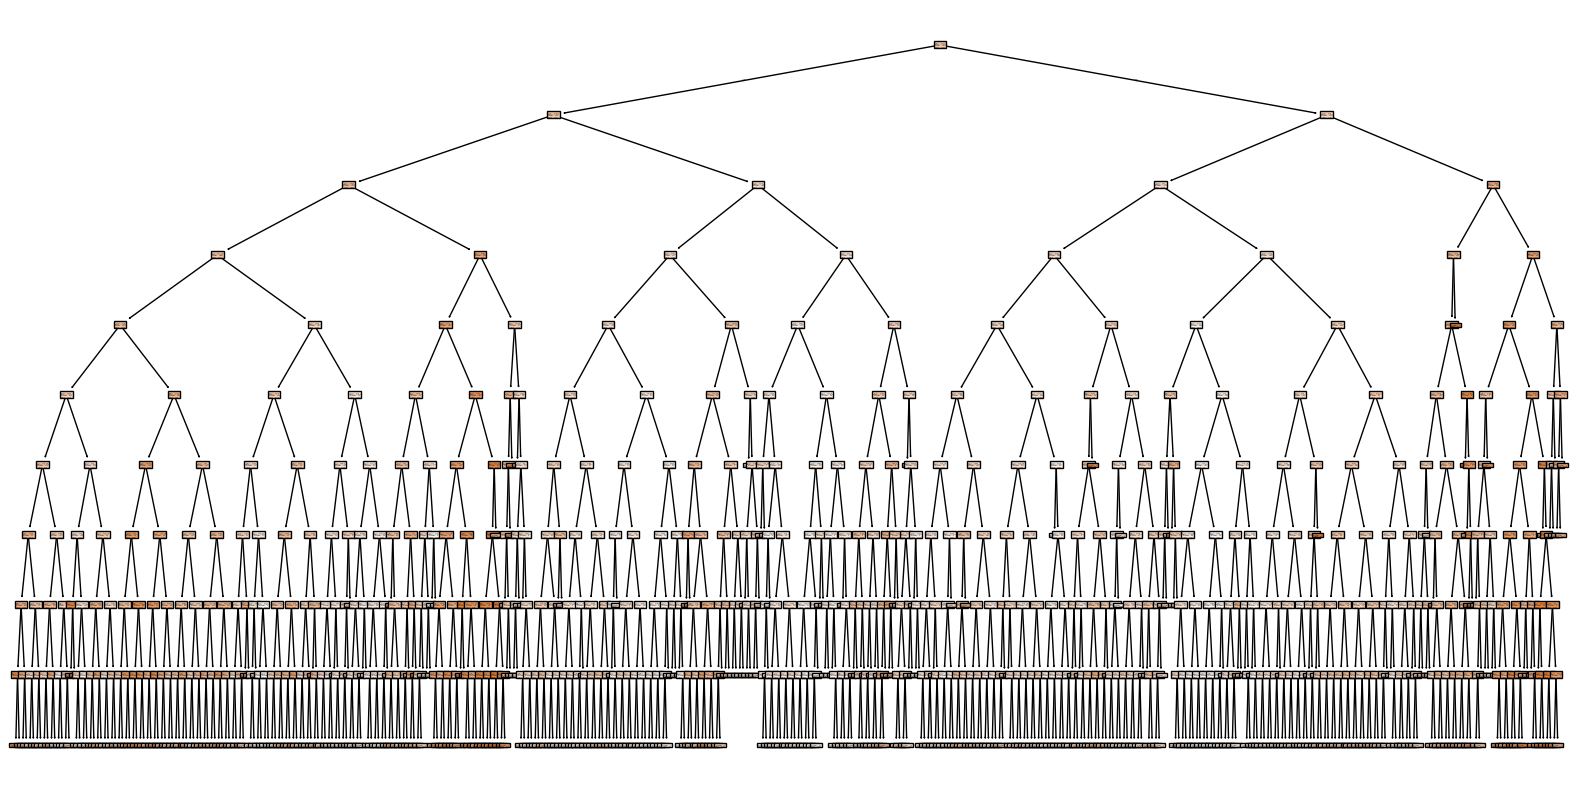

In [19]:
from sklearn import tree
plt.figure(figsize = (20,10))
tree.plot_tree(final_model, filled = True)


In [20]:
r2_score(y_test, final_model.predict(x_test))

0.5437951550984887